# Lab 2: Linear and polynomial regression

Regression analysis of 2020 mean income by age, using `inc_subset.csv` and `inc_utf.csv`. Income values retain the units provided in the datasets. Run the cells in order.

## Task 1: Load and inspect the subset

The loader uses basic file I/O, without pandas or a CSV library for parsing. Pandas holds the records after loading. The unnamed CSV column is a saved index and is not used as a predictor.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

candidates = [Path.cwd(), *Path.cwd().parents]
BASE_DIR = next((p for p in candidates if (p / "inc_subset.csv").is_file()
                 and (p / "inc_utf.csv").is_file()), None)
if BASE_DIR is None:
    raise FileNotFoundError("Open this notebook inside the Lab 2 project containing both CSV files.")
subset_path = BASE_DIR / "inc_subset.csv"
full_path = BASE_DIR / "inc_utf.csv"

def load_csv_basic(path, field_types=None):
    """Load a CSV file into a list of dicts using only basic file I/O (no csv/pandas)."""
    field_types = field_types or {}
    with open(path, "r", encoding="utf-8-sig") as file:
        raw_lines = file.read().splitlines()

    lines = [line for line in raw_lines if line.strip() != ""]
    if not lines:
        raise ValueError(f"Empty input file: {path}")
    header = [field.strip() or "source_index" for field in lines[0].split(",")]
    if len(header) != len(set(header)):
        raise ValueError("Duplicate column names")

    rows = []
    for line_number, line in enumerate(lines[1:], start=2):
        values = [field.strip() for field in line.split(",")]
        if len(values) != len(header):
            raise ValueError(f"{path}, record {line_number}: unexpected field count")
        row = dict(zip(header, values))
        for field, caster in field_types.items():
            row[field] = caster(row[field])
        rows.append(row)
    return rows

subset_rows = load_csv_basic(subset_path, field_types={"age": int, "2020": float})

# Inspect subset_rows here; header/values/row are local to the loader.
print(f"Loaded {len(subset_rows)} rows, header keys: {list(subset_rows[0].keys())}")
for row in subset_rows[:5]:
    print(row)

# Pandas is only used here to hold the already-parsed values, per the task instructions.
subset = pd.DataFrame(subset_rows)
subset["age"] = subset["age"].astype(int)
subset["2020"] = subset["2020"].astype(float)

print(f"Subset: {len(subset)} rows")
display(subset.head(10))


Loaded 30 rows, header keys: ['source_index', 'age', '2020']
{'source_index': '4', 'age': 20, '2020': 129.24285714285713}
{'source_index': '5', 'age': 21, '2020': 146.3095238095238}
{'source_index': '6', 'age': 22, '2020': 164.0}
{'source_index': '7', 'age': 23, '2020': 182.3952380952381}
{'source_index': '8', 'age': 24, '2020': 202.0761904761905}
Subset: 30 rows


,source_index,age,2020
0,4,20,129.242857
1,5,21,146.309524
2,6,22,164.000000
3,7,23,182.395238
4,8,24,202.076190
5,9,25,224.138095
6,10,26,242.619048
7,11,27,258.233333
8,12,28,271.528571
9,13,29,282.833333


The subset contains **30 ages, 20–49 inclusive**; age 50 is not present despite the handout's description.

**Debugger versus print:** a debugger is useful for pausing inside the loading loop to inspect an incorrectly converted field. Printouts are convenient for quickly checking the row count and sample records.

**Required debugger check:** set a breakpoint inside `load_csv_basic` at `row = dict(zip(header, values))`. Inspect `header` and `values`, then step through conversion to inspect `row`. Compare these with the printed records. Repeat this inspection for the full-file load in Task 3; running the notebook alone does not perform this interactive check.

## Task 2: Linear regression on the subset

### 2.1 Training and validation split

We use 24 training ages and 6 validation ages (80/20). Training data estimates the coefficients; validation data evaluates predictions on held-out ages. A fixed seed makes the split reproducible.

Random sampling is suitable for assessing predictions within the observed age range. With only six validation ages, the result is sensitive to the split. Holding out the oldest ages instead would assess extrapolation, not the same prediction problem.

We fit $\hat y=a+bx$ using vectorized NumPy operations:

$$b=\frac{n\sum xy-\sum x\sum y}{n\sum x^2-(\sum x)^2},\qquad a=\bar y-b\bar x.$$

The slope is the predicted income change per year of age. The intercept corresponds to age zero, outside the observed range. MSE is implemented manually as $\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat y_i)^2$.

In [2]:
def split_data(frame, validation_fraction=0.2, seed=42):
    rng = np.random.default_rng(seed)
    order = np.arange(len(frame))
    rng.shuffle(order)
    n_valid = int(round(len(frame) * validation_fraction))
    valid = frame.iloc[order[:n_valid]].sort_values("age").reset_index(drop=True)
    train = frame.iloc[order[n_valid:]].sort_values("age").reset_index(drop=True)
    return train, valid

def fit_manual_linear(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    slope = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x ** 2) - np.sum(x) ** 2)
    intercept = (np.sum(y) - slope * np.sum(x)) / n
    return intercept, slope

def mse(actual, predicted):
    return float(np.mean((np.asarray(actual) - np.asarray(predicted)) ** 2))
subset_train, subset_valid = split_data(subset)
print(f"Train rows: {len(subset_train)}, Validation rows: {len(subset_valid)}")

Train rows: 24, Validation rows: 6


### 2.2 Scatter plot and regression line

Model: predicted income = -29.862003 + 9.919898 x age


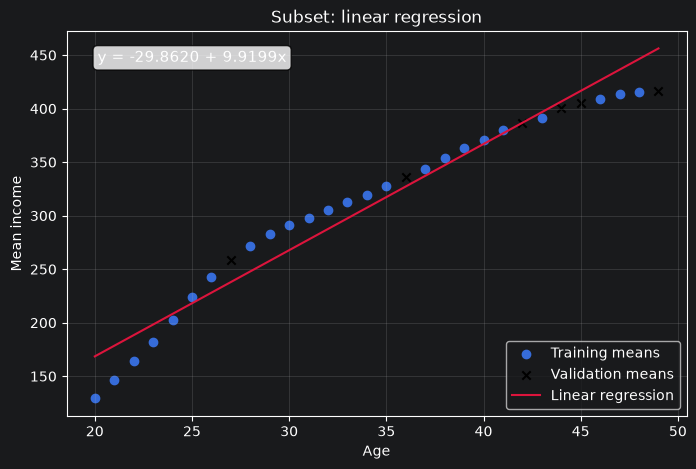

In [3]:
a, b = fit_manual_linear(subset_train["age"], subset_train["2020"])
print(f"Model: predicted income = {a:.6f} + {b:.6f} x age")

plt.figure(figsize=(8, 5))
plt.scatter(subset_train["age"], subset_train["2020"], label="Training means")
plt.scatter(subset_valid["age"], subset_valid["2020"], marker="x", color="black", label="Validation means")
x = np.linspace(subset["age"].min(), subset["age"].max(), 200)
plt.plot(x, a + b * x, color="crimson", label="Linear regression")
plt.xlabel("Age"); plt.ylabel("Mean income"); plt.title("Subset: linear regression")
formula = f"y = {a:.4f} + {b:.4f}x"
plt.text(0.05, 0.95, formula, transform=plt.gca().transAxes, fontsize=11,
          va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.legend(); plt.grid(alpha=0.25); plt.show()


### 2.3 Validation predictions

The predictions follow the increasing income trend, but the line misses the flattening at higher ages.

In [4]:
subset_valid["predicted"] = a + b * subset_valid["age"]
display(subset_valid[["age", "2020", "predicted"]].round(3))

,age,2020,predicted
0,27,258.233,237.975
1,36,335.724,327.254
2,42,386.148,386.774
3,44,400.343,406.614
4,45,405.500,416.533
5,49,416.252,456.213


### 2.4–2.5 MSE and interpretation

In [5]:
subset_mse = mse(subset_valid["2020"], subset_valid["predicted"])
print(f"Validation MSE: {subset_mse:.6f}")

Validation MSE: 373.403985


The validation MSE is **373.404 squared income units**: the average squared difference between observed and predicted income. Larger errors contribute more strongly because they are squared. The positive slope captures the overall increase, so linear regression is a reasonable simple approximation for this subset, although the curvature shows it is not a perfect fit.

## Task 3: Linear regression on the full dataset

### 3.1 Load, clean and group by age

We reuse the same loader, convert age labels to integers and income to floats, then calculate the mean across regions for each age. Inspect the loader in the debugger as in Task 1 and compare with the printed records.

In [6]:
full_rows = load_csv_basic(full_path)

print(f"Loaded {len(full_rows)} full-file records")
print("First:", full_rows[0])
print("Last:", full_rows[-1])
full_raw = pd.DataFrame(full_rows)
display(full_raw.head(10))

def extract_leading_int(text):
    """Extract the first run of digits in a string, e.g. '16 years' -> 16."""
    digits = ""
    started = False
    for ch in text:
        if ch.isdigit():
            digits += ch
            started = True
        elif started:
            break
    return int(digits) if digits else None

for row in full_rows:
    row["age"] = extract_leading_int(row["age"])
    row["2020"] = float(row["2020"])

full = pd.DataFrame(full_rows)
full_by_age = full.groupby("age", as_index=False)["2020"].mean().sort_values("age").reset_index(drop=True)

print(f"Full dataset: {len(full)} rows, {full['age'].nunique()} distinct age groups")
print(f"Grouped by age: {len(full_by_age)} rows (compare to {subset['age'].nunique()} age groups in the subset)")
display(full.head(10))
display(full_by_age.head(10))

Loaded 1785 full-file records
First: {'source_index': '0', 'region': '01 Stockholm county', 'age': '16 years', '2020': '4.6'}
Last: {'source_index': '1784', 'region': '25 Norrbotten county', 'age': '100+ years', '2020': '235.3'}


,source_index,region,age,2020
0,0,01 Stockholm county,16 years,4.6
1,1,01 Stockholm county,17 years,8.8
2,2,01 Stockholm county,18 years,17.8
3,3,01 Stockholm county,19 years,52.5
4,4,01 Stockholm county,20 years,112.0
5,5,01 Stockholm county,21 years,127.9
6,6,01 Stockholm county,22 years,147.1
7,7,01 Stockholm county,23 years,167.9
8,8,01 Stockholm county,24 years,191.8
9,9,01 Stockholm county,25 years,225.2


Full dataset: 1785 rows, 85 distinct age groups
Grouped by age: 85 rows (compare to 30 age groups in the subset)


,source_index,region,age,2020
0,0,01 Stockholm county,16,4.6
1,1,01 Stockholm county,17,8.8
2,2,01 Stockholm county,18,17.8
3,3,01 Stockholm county,19,52.5
4,4,01 Stockholm county,20,112.0
5,5,01 Stockholm county,21,127.9
6,6,01 Stockholm county,22,147.1
7,7,01 Stockholm county,23,167.9
8,8,01 Stockholm county,24,191.8
9,9,01 Stockholm county,25,225.2


,age,2020
0,16,5.471429
1,17,10.552381
2,18,22.390476
3,19,65.376190
4,20,129.242857
5,21,146.309524
6,22,164.000000
7,23,182.395238
8,24,202.076190
9,25,224.138095


There are **1,785 records, 21 regions and 85 age labels**, compared with 30 ages in the subset. Ages are 16–99 plus **100+**, represented by 100 for modelling. This last value is a lower-bound proxy. Each region receives equal weight in the mean; this is not a population-weighted national average.

### 3.2 Training and validation split

The same 80/20 procedure gives 68 training ages and 17 validation ages.

In [7]:
full_train, full_valid = split_data(full_by_age)
print(f"Train rows: {len(full_train)}, Validation rows: {len(full_valid)}")

Train rows: 68, Validation rows: 17


### 3.3 Scatter plot and regression line

Model: predicted income = 325.144061 + -0.756280 x age


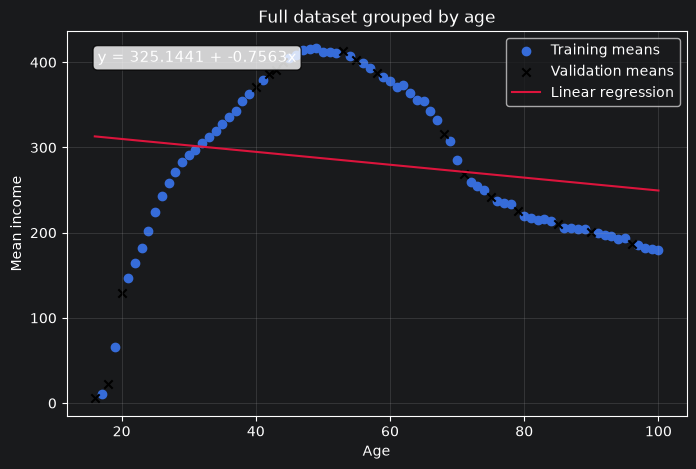

In [8]:
full_a, full_b = fit_manual_linear(full_train["age"], full_train["2020"])
print(f"Model: predicted income = {full_a:.6f} + {full_b:.6f} x age")

plt.figure(figsize=(8, 5))
plt.scatter(full_train["age"], full_train["2020"], label="Training means")
plt.scatter(full_valid["age"], full_valid["2020"], marker="x", color="black", label="Validation means")
x = np.linspace(full_by_age["age"].min(), full_by_age["age"].max(), 300)
plt.plot(x, full_a + full_b * x, color="crimson", label="Linear regression")
plt.xlabel("Age"); plt.ylabel("Mean income"); plt.title("Full dataset grouped by age")
formula = f"y = {full_a:.4f} + {full_b:.4f}x"
plt.text(0.05, 0.95, formula, transform=plt.gca().transAxes, fontsize=11,
          va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.legend(); plt.grid(alpha=0.25); plt.show()


### 3.4 Validation predictions

The fitted line decreases with age, while the observed income rises toward middle age and then falls. The line therefore overpredicts young ages and underpredicts much of the middle-age peak. The held-out data serves as the validation set (called the test dataset in Task 3.4).

In [9]:
full_valid["predicted"] = full_a + full_b * full_valid["age"]
display(full_valid[["age", "2020", "predicted"]].round(3))

,age,2020,predicted
0,16,5.471,313.044
1,18,22.390,311.531
2,20,129.243,310.018
3,40,371.095,294.893
4,42,386.148,293.380
5,43,391.448,292.624
6,44,400.343,291.868
7,53,413.462,285.061
8,55,402.324,283.549
9,58,387.529,281.280


### 3.5–3.6 MSE and comparison

In [10]:
full_mse = mse(full_valid["2020"], full_valid["predicted"])
print(f"Validation MSE: {full_mse:.6f}")

Validation MSE: 17814.366820


The full-data validation MSE is **17,814.367 squared income units**, compared with **373.404** for the subset. The broader age range includes a rise and fall that a single straight line cannot represent. These scores describe different validation sets, so the difference is not evidence that more data itself makes regression worse.

## Task 4: Reflections

**4.1 Differences:** the subset graph shows an increasing trend with some flattening; its positive-slope line gives predictions relatively close to the observations. The full-data graph has a middle-age peak; its negative-slope line misses this shape and produces much larger prediction errors and MSE. A single straight line underfits the full age range.

**4.2 Improvements:** polynomial regression can model the curvature. Choose its degree using validation MSE rather than assuming that a higher degree is better. Repeated splits or cross-validation could assess how sensitive the choice is to the held-out ages.

## Task 5: Polynomial regression with hyperparameter tuning

### 5.1–5.2 Fit four polynomial degrees

Polynomial regression is linear in its coefficients: $\hat y=b_0+b_1z+\cdots+b_dz^d$. `PolynomialFeatures` creates the powers, and `LinearRegression` fits their coefficients.

We compare degrees **2, 3, 5 and 8** on the same training and validation ages as Task 3. Age is standardized using training data only before creating powers, keeping high-degree calculations numerically stable. The pipeline applies that same transformation to validation data.

In [11]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

degrees = [2, 3, 5, 8]
polynomial_results = []
polynomial_models = {}
X_train = full_train[["age"]]
y_train = full_train["2020"]
X_valid = full_valid[["age"]]
y_valid = full_valid["2020"]

for degree in degrees:
    model = make_pipeline(StandardScaler(),
                          PolynomialFeatures(degree=degree, include_bias=False),
                          LinearRegression())
    model.fit(X_train, y_train)
    polynomial_results.append({
        "degree": degree,
        "validation_MSE": mse(y_valid, model.predict(X_valid))})
    polynomial_models[degree] = model

polynomial_results = pd.DataFrame(polynomial_results)
best_degree = int(polynomial_results.loc[polynomial_results["validation_MSE"].idxmin(), "degree"])
best_model = polynomial_models[best_degree]
best_mse = float(polynomial_results["validation_MSE"].min())
display(polynomial_results.round(3))
print(f"Best of the four candidates: degree {best_degree}")
print(f"Validation MSE: {best_mse:.3f}")


,degree,validation_MSE
0,2,3995.569
1,3,259.964
2,5,257.543
3,8,186.570


Best of the four candidates: degree 8
Validation MSE: 186.570


### 5.3 Best degree and explanation

**Degree 8** has the lowest validation MSE among the tested choices: **186.570**, compared with **17,814.367** for the full-data linear model. Its flexibility captures the curved income pattern more accurately on these validation ages.

This is the best degree for these candidates and this split, not a universal optimum. The curve predicts negative income near age 16, so lower overall MSE does not guarantee realistic predictions everywhere. Since the validation data selects the degree, its score is not an independent final test result.

### 5.4 Best polynomial and linear regression curves

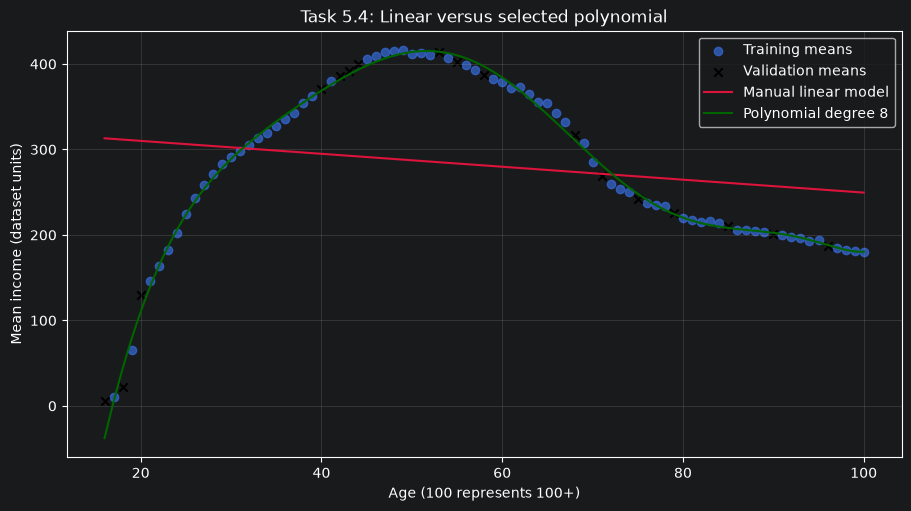

In [12]:
x_curve = pd.DataFrame({"age": np.linspace(full_by_age["age"].min(), full_by_age["age"].max(), 400)})
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.scatter(full_train["age"], y_train, label="Training means", alpha=0.7)
ax.scatter(full_valid["age"], y_valid, label="Validation means", marker="x", color="black")
ax.plot(x_curve["age"], full_a + full_b * x_curve["age"], color="crimson", label="Manual linear model")
ax.plot(x_curve["age"], best_model.predict(x_curve), color="darkgreen", label=f"Polynomial degree {best_degree}")
ax.set(xlabel="Age (100 represents 100+)", ylabel="Mean income (dataset units)", title="Task 5.4: Linear versus selected polynomial")
ax.legend(); ax.grid(alpha=0.25); plt.show()
